In [1]:
#Check GPU enabled
import torch
print(torch.cuda.is_available())    

True


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Load MidiDatasets

In [3]:
from pathlib import Path
import shutil

# midi_directory and excluded_directory are assumed to be Path objects or strings
midi_directory = Path("/content/drive/MyDrive/capstone_team_3/MidiDatasets/590-Classical-music-midi")
#  List of directories 
print("List of directories in midi_directory:")
for item in midi_directory.iterdir():
    if item.is_dir():
        print(item.name)

List of directories in midi_directory:
muss
borodin
beeth
mozart
debussy
bach
haydn
granados
schumann
albeniz
grieg
mendelssohn
burgm
chopin
liszt
balakir
tschai
schubert
brahms


In [4]:
# Load the MIDI files and extract features using pretty_midi
import pretty_midi
import os   
midi_files = []
for root, dirs, files in os.walk(midi_directory):
    for file in files:
        if file.endswith('.mid') or file.endswith('.midi'):
            midi_files.append(os.path.join(root, file))
print(f"Total MIDI files found: {len(midi_files)}")
# Example of loading a MIDI file and extracting features
if midi_files:
    midi_path = midi_files[0]  # Load the first MIDI file as an example
    midi_data = pretty_midi.PrettyMIDI(midi_path)
    print(f"Loaded MIDI file: {midi_path}")
    print(f"Number of instruments: {len(midi_data.instruments)}")
    print(f"Total duration: {midi_data.get_end_time()} seconds")



Total MIDI files found: 292
Loaded MIDI file: /content/drive/MyDrive/capstone_team_3/MidiDatasets/590-Classical-music-midi/muss/muss_6.mid
Number of instruments: 2
Total duration: 126.4340885 seconds


In [5]:
#  extract features from MIDI data with duration, pitch_diff, velocity
import numpy as np
def extract_features(midi_data):
        features = []
        previous_pitch = None
        for instrument in midi_data.instruments:
            for note in instrument.notes:
                #  duration, pitch, velocity, pitch_diff    
                pitch_diff = note.pitch - previous_pitch if previous_pitch is not None else 0
                features.append([note.end - note.start, pitch_diff, note.velocity])
                previous_pitch = note.pitch
        return np.array(features)   

In [6]:

midi_features = []
for midi_path in midi_files:
    midi_data = pretty_midi.PrettyMIDI(midi_path)
    features = extract_features(midi_data)
    midi_features.append(features)
print(f"Extracted features from {len(midi_features)} MIDI files.")

Extracted features from 292 MIDI files.


In [7]:
# Convert the list of features into a format suitable for training (e.g., numpy array)
midi_features_array = np.array(midi_features, dtype=object)  # Using dtype=object to handle variable-length feature arrays
print(f"Shape of MIDI features array: {midi_features_array.shape}")
#Store the extracted features for later use as CSV or binary file
import pandas as pd
# Convert the list of features into a DataFrame for easier storage and manipulation
features_df = pd.DataFrame(midi_features_array, columns=['features'])
# Save the DataFrame to a CSV file
features_df.to_csv('/content/drive/MyDrive/capstone_team_3/midi_features_v1.csv', index=False)
print("MIDI features saved to CSV file.")   

Shape of MIDI features array: (292,)
MIDI features saved to CSV file.


### Visualizaton of Midi

Text(0, 0.5, 'Frequency')

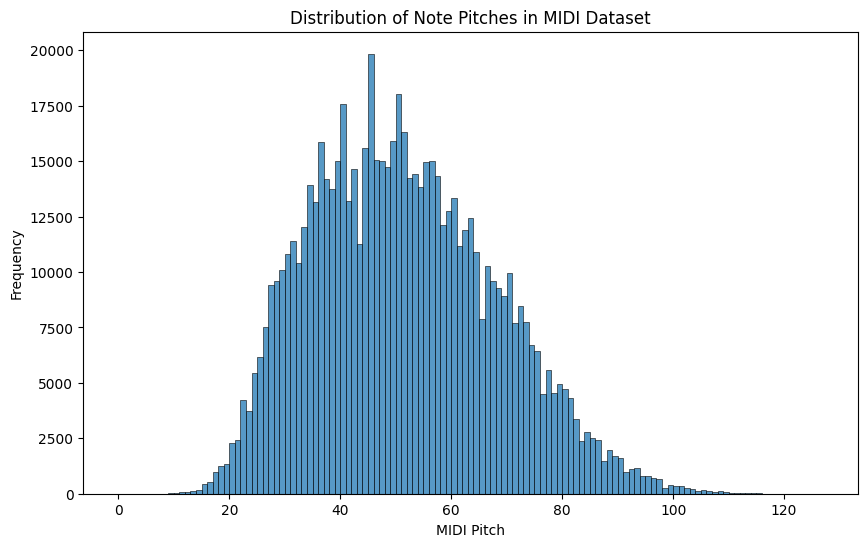

In [8]:
# Create the distribution of features for training the model
# This step will depend on the specific model architecture and training requirements
# For example, you might want to create sequences of features for training a sequence model like an LSTM or Transformer.

import seaborn as sns
import matplotlib.pyplot as plt
# Example: Visualize the distribution of note pitches across all MIDI files
all_pitches = []
for features in midi_features:
    if features.size > 0:  # Check if there are features to avoid errors
        all_pitches.extend(features[:, 2])  # Extract the pitch column (index 2)
# Plot the distribution of note pitches using a histogram
plt.figure(figsize=(10, 6))
sns.histplot(all_pitches, bins=range(0, 128), kde=False)
plt.title('Distribution of Note Pitches in MIDI Dataset')
plt.xlabel('MIDI Pitch')
plt.ylabel('Frequency')     

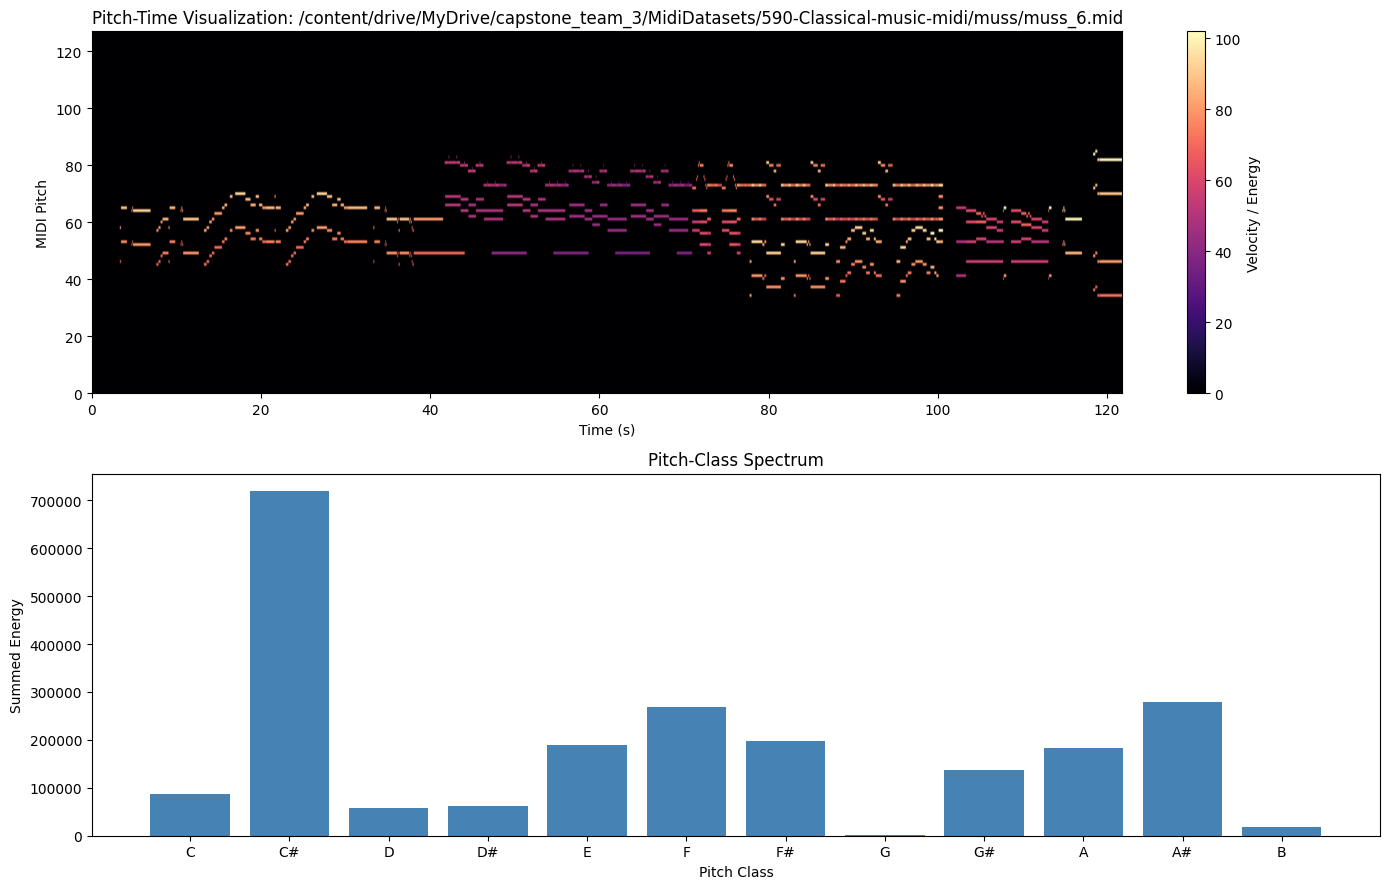

In [28]:
# Visualize one MIDI file by pitch over time and pitch-class spectrum
import numpy as np
import matplotlib.pyplot as plt

if not midi_files:
    print("No MIDI files available to visualize.")
else:
    # Pick a MIDI file (you can change index to inspect others)
    midi_idx = 0
    midi_path = midi_files[midi_idx]
    midi_data = pretty_midi.PrettyMIDI(midi_path)

    # Piano roll: rows=pitches (0-127), cols=time frames
    fs = 100  # frames per second
    piano_roll = midi_data.get_piano_roll(fs=fs)

    # Build a simple pitch-class spectrum (C..B) from total note energy
    chroma = np.zeros(12)
    if piano_roll.size > 0:
        for pitch in range(128):
            chroma[pitch % 12] += piano_roll[pitch].sum()

    # Time axis for piano roll
    time_axis = np.arange(piano_roll.shape[1]) / fs if piano_roll.size > 0 else np.array([0])

    fig, axes = plt.subplots(2, 1, figsize=(14, 9))

    # Plot 1: Pitch-time heatmap
    if piano_roll.size > 0:
        im = axes[0].imshow(
            piano_roll,
            origin='lower',
            aspect='auto',
            cmap='magma',
            extent=[time_axis.min(), time_axis.max(), 0, 127]
        )
        fig.colorbar(im, ax=axes[0], label='Velocity / Energy')
    axes[0].set_title(f'Pitch-Time Visualization: {midi_path}')
    axes[0].set_xlabel('Time (s)')
    axes[0].set_ylabel('MIDI Pitch')

    # Plot 2: Pitch-class spectrum
    note_names = ['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B']
    axes[1].bar(note_names, chroma, color='steelblue')
    axes[1].set_title('Pitch-Class Spectrum')
    axes[1].set_xlabel('Pitch Class')
    axes[1].set_ylabel('Summed Energy')

    plt.tight_layout()
    plt.show()

In [39]:
# Convert the pitch into  windowed sequences for training a sequence model
def create_sequences(features, sequence_length=100):
    sequences = []
    for i in range(len(features) - sequence_length):
        seq = features[i:i + sequence_length]
        sequences.append(seq)
    return np.array(sequences)

# Covvert the all the midi features into sequences for training,  Each sequence will be a window of 50 notes (or other features) for training a model like an LSTM or Transformer. Label the sequences appropriately for supervised learning, give the name of the midi file as the label for each sequence.
all_sequences = []
for midi_path, features in zip(midi_files, midi_features):
    if features.size > 0:  # Check if there are features to avoid errors
        sequences = create_sequences(features)
        file_name = os.path.basename(midi_path)  # Get the file name from the path
        labels = [file_name] * len(sequences)  # Label each sequence with the MIDI file name
        all_sequences.extend(zip(sequences, labels))
print(f"Total sequences created: {len(all_sequences)}")

# Create a DF for the sequences and labels
sequences_df = pd.DataFrame(all_sequences, columns=['sequence', 'label'])
print(f"Shape of sequences DataFrame: {sequences_df.shape}")


Total sequences created: 676395
Shape of sequences DataFrame: (676395, 2)


In [40]:
# Shape of the each sequence
sequences_df['sequence'].head(1).values[0].shape

(100, 3)

In [41]:
sequences_df['sequence'].head(1).values[0]

array([[ 1.23967000e-01,  0.00000000e+00,  8.00000000e+01],
       [ 7.10059000e-01,  7.00000000e+00,  8.80000000e+01],
       [ 8.87573750e-02, -1.00000000e+00,  8.00000000e+01],
       [ 8.87573750e-02,  1.00000000e+00,  8.00000000e+01],
       [ 2.08092600e+00, -1.00000000e+00,  9.20000000e+01],
       [ 2.42424333e-01, -7.00000000e+00,  8.00000000e+01],
       [ 2.42424333e-01,  1.00000000e+00,  8.00000000e+01],
       [ 2.42424333e-01,  2.00000000e+00,  8.00000000e+01],
       [ 7.05068833e-01,  1.00000000e+00,  8.60000000e+01],
       [ 1.23967000e-01, -3.00000000e+00,  8.00000000e+01],
       [ 6.70391000e-01,  7.00000000e+00,  8.60000000e+01],
       [ 1.00000000e-01, -1.00000000e+00,  8.00000000e+01],
       [ 1.00000000e-01,  1.00000000e+00,  8.00000000e+01],
       [ 1.00000000e-01, -1.00000000e+00,  8.00000000e+01],
       [ 1.84615500e+00, -3.00000000e+00,  9.00000000e+01],
       [ 3.07692500e-01, -4.00000000e+00,  8.20000000e+01],
       [ 3.07692500e-01,  1.00000000e+00

In [42]:
# Save the sequences as pickle file
sequences_df.to_pickle('/content/drive/MyDrive/capstone_team_3/midi_sequences_v1_100.pkl')
print("MIDI sequences and labels saved to pickle file.")


MIDI sequences and labels saved to pickle file.


In [43]:
# Sample a few sequences and labels to verify
print("Sample sequences and labels:")
print(sequences_df.head())  

Sample sequences and labels:
                                            sequence       label
0  [[0.12396699999999994, 0.0, 80.0], [0.71005899...  muss_6.mid
1  [[0.7100589999999998, 7.0, 88.0], [0.088757375...  muss_6.mid
2  [[0.08875737500000014, -1.0, 80.0], [0.0887573...  muss_6.mid
3  [[0.08875737500000014, 1.0, 80.0], [2.080926, ...  muss_6.mid
4  [[2.080926, -1.0, 92.0], [0.24242433333333313,...  muss_6.mid


In [44]:
# Split the dataset into training and testing sets
from sklearn.model_selection import train_test_split
train_df, test_df = train_test_split(sequences_df, test_size=0.2, random_state=42)
print(f"Training set size: {len(train_df)}")
print(f"Testing set size: {len(test_df)}")  

Training set size: 541116
Testing set size: 135279


In [45]:
# Baseline sequence-classification setup and similarity helpers
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
import torch.optim as optim

def cosine_similarity(vec1, vec2):
    vec1 = np.asarray(vec1, dtype=np.float32)
    vec2 = np.asarray(vec2, dtype=np.float32)
    dot_product = np.dot(vec1, vec2)
    norm_vec1 = np.linalg.norm(vec1)
    norm_vec2 = np.linalg.norm(vec2)
    if norm_vec1 == 0 or norm_vec2 == 0:
        return 0.0
    return float(dot_product / (norm_vec1 * norm_vec2))

def features_to_vector(features):
    features = np.asarray(features, dtype=np.float32)
    if features.ndim == 1:
        features = features.reshape(1, -1)
    summary_vector = np.concatenate([
        features.mean(axis=0),
        features.std(axis=0),
        features.min(axis=0),
        features.max(axis=0)
    ])
    return summary_vector.astype(np.float32)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


### Baseline LSTM sequence classifier
Prepare normalized sequence tensors, train a simple LSTM classifier, and compare learned embeddings with cosine similarity.

In [46]:
# Prepare normalized tensors and dataloaders
train_sequences = np.stack(train_df['sequence'].to_numpy()).astype(np.float32)
test_sequences = np.stack(test_df['sequence'].to_numpy()).astype(np.float32)

feature_mean = train_sequences.reshape(-1, train_sequences.shape[-1]).mean(axis=0)
feature_std = train_sequences.reshape(-1, train_sequences.shape[-1]).std(axis=0) + 1e-6

X_train = (train_sequences - feature_mean) / feature_std
X_test = (test_sequences - feature_mean) / feature_std

label_encoder = LabelEncoder()
label_encoder.fit(sequences_df['label'])
y_train = label_encoder.transform(train_df['label'])
y_test = label_encoder.transform(test_df['label'])

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

batch_size = 64
train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=batch_size, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=batch_size, shuffle=False)

input_dim = X_train.shape[-1]
sequence_length = X_train.shape[1]
num_classes = len(label_encoder.classes_)

print(f'Train tensor shape: {X_train_tensor.shape}')
print(f'Test tensor shape: {X_test_tensor.shape}')
print(f'Input dimension: {input_dim}, Sequence length: {sequence_length}, Classes: {num_classes}')

Train tensor shape: torch.Size([541116, 100, 3])
Test tensor shape: torch.Size([135279, 100, 3])
Input dimension: 3, Sequence length: 100, Classes: 292


In [47]:
# Define and train a baseline LSTM classifier
class LSTMSequenceClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes, num_layers=2, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_dim, num_classes)

    def forward(self, x, return_embedding=False):
        _, (hidden_state, _) = self.lstm(x)
        embedding = self.dropout(hidden_state[-1])
        logits = self.classifier(embedding)
        if return_embedding:
            return logits, embedding
        return logits

hidden_dim = 128
learning_rate = 1e-3
epochs = 5

model = LSTMSequenceClassifier(input_dim=input_dim, hidden_dim=hidden_dim, num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

history = []
for epoch in range(epochs):
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for batch_inputs, batch_labels in train_loader:
        batch_inputs = batch_inputs.to(device)
        batch_labels = batch_labels.to(device)

        optimizer.zero_grad()
        logits = model(batch_inputs)
        loss = criterion(logits, batch_labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * batch_inputs.size(0)
        train_correct += (logits.argmax(dim=1) == batch_labels).sum().item()
        train_total += batch_labels.size(0)

    model.eval()
    test_loss = 0.0
    test_correct = 0
    test_total = 0

    with torch.no_grad():
        for batch_inputs, batch_labels in test_loader:
            batch_inputs = batch_inputs.to(device)
            batch_labels = batch_labels.to(device)

            logits = model(batch_inputs)
            loss = criterion(logits, batch_labels)

            test_loss += loss.item() * batch_inputs.size(0)
            test_correct += (logits.argmax(dim=1) == batch_labels).sum().item()
            test_total += batch_labels.size(0)

    epoch_metrics = {
        'epoch': epoch + 1,
        'train_loss': train_loss / train_total,
        'train_accuracy': train_correct / train_total,
        'test_loss': test_loss / test_total,
        'test_accuracy': test_correct / test_total
    }
    history.append(epoch_metrics)
    print(
        f"Epoch {epoch + 1}/{epochs} - "
        f"train_loss: {epoch_metrics['train_loss']:.4f}, "
        f"train_accuracy: {epoch_metrics['train_accuracy']:.4f}, "
        f"test_loss: {epoch_metrics['test_loss']:.4f}, "
        f"test_accuracy: {epoch_metrics['test_accuracy']:.4f}"
    )

history_df = pd.DataFrame(history)
history_df

Epoch 1/5 - train_loss: 4.0693, train_accuracy: 0.1182, test_loss: 2.5954, test_accuracy: 0.3607
Epoch 2/5 - train_loss: 2.0023, train_accuracy: 0.4803, test_loss: 0.9450, test_accuracy: 0.7632
Epoch 3/5 - train_loss: 0.9211, train_accuracy: 0.7444, test_loss: 0.3084, test_accuracy: 0.9258
Epoch 4/5 - train_loss: 0.4607, train_accuracy: 0.8673, test_loss: 0.1125, test_accuracy: 0.9748
Epoch 5/5 - train_loss: 0.2722, train_accuracy: 0.9206, test_loss: 0.0822, test_accuracy: 0.9800


,epoch,train_loss,train_accuracy,test_loss,test_accuracy
0,1,4.069262,0.118158,2.595377,0.360706
1,2,2.002318,0.480263,0.945035,0.763178
2,3,0.921072,0.744436,0.308397,0.925753
3,4,0.460722,0.867339,0.112494,0.974771
4,5,0.272187,0.920634,0.082213,0.979975


In [48]:
# Evaluate predictions and compare embeddings with cosine similarity
model.eval()
all_predictions = []
all_targets = []
train_embedding_sums = np.zeros((num_classes, hidden_dim), dtype=np.float32)
train_embedding_counts = np.zeros(num_classes, dtype=np.int32)

with torch.no_grad():
    for batch_inputs, batch_labels in train_loader:
        batch_inputs = batch_inputs.to(device)
        batch_labels = batch_labels.to(device)
        _, embeddings = model(batch_inputs, return_embedding=True)
        embeddings = embeddings.cpu().numpy()
        labels_np = batch_labels.cpu().numpy()

        for embedding, label in zip(embeddings, labels_np):
            train_embedding_sums[label] += embedding
            train_embedding_counts[label] += 1

    for batch_inputs, batch_labels in test_loader:
        batch_inputs = batch_inputs.to(device)
        batch_labels = batch_labels.to(device)
        logits, _ = model(batch_inputs, return_embedding=True)
        predictions = logits.argmax(dim=1)
        all_predictions.extend(predictions.cpu().numpy())
        all_targets.extend(batch_labels.cpu().numpy())

prototype_embeddings = train_embedding_sums / np.maximum(train_embedding_counts[:, None], 1)
test_accuracy = accuracy_score(all_targets, all_predictions)
print(f'Test accuracy: {test_accuracy:.4f}')

prediction_preview = pd.DataFrame({
    'true_label': label_encoder.inverse_transform(all_targets[:10]),
    'predicted_label': label_encoder.inverse_transform(all_predictions[:10])
})
prediction_preview

sample_index = 0
sample_sequence = X_test_tensor[sample_index:sample_index + 1].to(device)
sample_true_label = label_encoder.inverse_transform([y_test[sample_index]])[0]

with torch.no_grad():
    sample_logits, sample_embedding = model(sample_sequence, return_embedding=True)
    sample_prediction = int(sample_logits.argmax(dim=1).item())
    sample_embedding = sample_embedding.squeeze(0).cpu().numpy()

similarity_rows = []
for class_index, class_name in enumerate(label_encoder.classes_):
    similarity_rows.append({
        'label': class_name,
        'cosine_similarity': cosine_similarity(sample_embedding, prototype_embeddings[class_index])
    })

similarity_df = pd.DataFrame(similarity_rows).sort_values('cosine_similarity', ascending=False).head(5)
print(f'Sample true label: {sample_true_label}')
print(f"Sample predicted label: {label_encoder.inverse_transform([sample_prediction])[0]}")
similarity_df

Test accuracy: 0.9800
Sample true label: muss_8.mid
Sample predicted label: muss_8.mid


,label,cosine_similarity
199,muss_8.mid,0.760112
77,chpn-p22.mid,0.535890
101,chpn_op35_1.mid,0.509503
173,liz_rhap15.mid,0.506815
79,chpn-p24.mid,0.494605


In [49]:
# Create test midi sequences  for midi_directory = Path("/content/drive/MyDrive/capstone_team_3/MidiDatasets/TestingSamples/MidiOutputs")
test_sequences = []
test_midi_directory = Path("/content/drive/MyDrive/capstone_team_3/MidiDatasets/TestingSamples/MidiOutputs")
test_files=[]
for root, dirs, files in os.walk(test_midi_directory):
    for file in files:
        if file.endswith('.mid') or file.endswith('.midi'):
            midi_path = os.path.join(root, file)
            midi_data = pretty_midi.PrettyMIDI(midi_path)
            features = extract_features(midi_data)
            file_name = os.path.basename(midi_path)  # Get the file name from the path
            test_sequences.append((features, file))  # Store features and filename as label
print(f"Total test MIDI sequences created: {len(test_sequences)}")




/usr/local/lib/python3.12/dist-packages/pretty_midi/pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(


Total test MIDI sequences created: 50


In [50]:
# merge the test sequences ,filename and features into a single list for evaluation
merged_test_sequences = []
# Store each sequence with the MIDI file name as label
for features, filename in test_sequences:
    if features.size > 0:
        sequences = create_sequences(features)
        for seq in sequences:
            merged_test_sequences.append((seq, filename))  # Store each sequence with the MIDI file name as label

In [51]:
# Create a DATAFRAME for the merged test sequences
test_df = pd.DataFrame(merged_test_sequences, columns=['sequence', 'label'])
print(f"Shape of merged test sequences DataFrame: {test_df.shape}")
print("Sample merged test sequences:")
print(test_df.head())

Shape of merged test sequences DataFrame: (210167, 2)
Sample merged test sequences:
                                            sequence  \
0  [[0.7999999999999998, 0.0, 44.0], [0.300000000...   
1  [[0.30000000000000027, 4.0, 47.0], [0.79999999...   
2  [[0.7999999999999998, 3.0, 49.0], [0.304166666...   
3  [[0.3041666666666667, -3.0, 52.0], [0.79999999...   
4  [[0.7999999999999998, 1.0, 54.0], [0.299999999...   

                       label  
0  Piano Sonata n12 K332.mid  
1  Piano Sonata n12 K332.mid  
2  Piano Sonata n12 K332.mid  
3  Piano Sonata n12 K332.mid  
4  Piano Sonata n12 K332.mid  


In [52]:
test_df

,sequence,label
0,"[[0.7999999999999998, 0.0, 44.0], [0.300000000...",Piano Sonata n12 K332.mid
1,"[[0.30000000000000027, 4.0, 47.0], [0.79999999...",Piano Sonata n12 K332.mid
2,"[[0.7999999999999998, 3.0, 49.0], [0.304166666...",Piano Sonata n12 K332.mid
3,"[[0.3041666666666667, -3.0, 52.0], [0.79999999...",Piano Sonata n12 K332.mid
4,"[[0.7999999999999998, 1.0, 54.0], [0.299999999...",Piano Sonata n12 K332.mid
...,...,...
210162,"[[0.05769224999994549, -1.0, 100.0], [0.057692...",Piano Sonata n29 Op106 ''Hammerklavier''.mid
210163,"[[0.05769224999994549, 1.0, 100.0], [0.0576922...",Piano Sonata n29 Op106 ''Hammerklavier''.mid
210164,"[[0.05769224999994549, -1.0, 100.0], [0.057692...",Piano Sonata n29 Op106 ''Hammerklavier''.mid
210165,"[[0.05769224999994549, 1.0, 100.0], [0.0576922...",Piano Sonata n29 Op106 ''Hammerklavier''.mid


In [ ]:
# Convert merged_test_sequences to X_test_external and run inference (preserve X_test for Music-BERT)
X_test_external_sequences = np.stack(test_df['sequence'].to_numpy()).astype(np.float32)
X_test_external = (X_test_external_sequences - feature_mean) / feature_std

# Predict label for each test sequence using cosine similarity to class prototypes
model.eval()
predicted_labels = []
with torch.no_grad():
    for seq in X_test_external:
        seq_tensor = torch.tensor(seq, dtype=torch.float32).unsqueeze(0).to(device)
        _, seq_embedding = model(seq_tensor, return_embedding=True)
        seq_embedding = seq_embedding.squeeze(0).cpu().numpy()

        similarities = [
            cosine_similarity(seq_embedding, prototype_embeddings[i])
            for i in range(num_classes)
        ]
        predicted_label_index = int(np.argmax(similarities))
        predicted_labels.append(label_encoder.inverse_transform([predicted_label_index])[0])

test_df['predicted_label'] = predicted_labels
print("Sample test sequences with predicted labels:")
print(test_df.head())

Sample test sequences with predicted labels:
                                            sequence  \
0  [[0.7999999999999998, 0.0, 44.0], [0.300000000...   
1  [[0.30000000000000027, 4.0, 47.0], [0.79999999...   
2  [[0.7999999999999998, 3.0, 49.0], [0.304166666...   
3  [[0.3041666666666667, -3.0, 52.0], [0.79999999...   
4  [[0.7999999999999998, 1.0, 54.0], [0.299999999...   

                       label predicted_label  
0  Piano Sonata n12 K332.mid    mz_333_3.mid  
1  Piano Sonata n12 K332.mid    mz_333_3.mid  
2  Piano Sonata n12 K332.mid    mz_333_3.mid  
3  Piano Sonata n12 K332.mid    mz_333_3.mid  
4  Piano Sonata n12 K332.mid    mz_333_3.mid  


In [54]:
# Store test_df with predicted labels to CSV for analysis
test_df.to_csv('/content/drive/MyDrive/capstone_team_3/test_sequences_with_predictions_v1.csv', index=False)
print("Test sequences with predicted labels saved to CSV file.")    

Test sequences with predicted labels saved to CSV file.


In [55]:
test_df[['sequence', 'predicted_label']].head(1).values

array([[array([[ 8.00000000e-01,  0.00000000e+00,  4.40000000e+01],
               [ 3.00000000e-01,  4.00000000e+00,  4.70000000e+01],
               [ 8.00000000e-01,  3.00000000e+00,  4.90000000e+01],
               [ 3.04166667e-01, -3.00000000e+00,  5.20000000e+01],
               [ 8.00000000e-01,  1.00000000e+00,  5.40000000e+01],
               [ 3.00000000e-01,  9.00000000e+00,  5.80000000e+01],
               [ 2.01342500e-01, -2.00000000e+00,  6.30000000e+01],
               [ 1.59396146e-01, -1.00000000e+00,  5.90000000e+01],
               [ 3.06208385e-01,  0.00000000e+00,  5.20000000e+01],
               [ 4.02685000e-01,  1.00000000e+00,  5.30000000e+01],
               [ 4.02685000e-01, -8.00000000e+00,  5.10000000e+01],
               [ 3.06208385e-01,  5.00000000e+00,  4.80000000e+01],
               [ 4.02685000e-01, -7.00000000e+00,  5.20000000e+01],
               [ 6.12420437e-01,  5.00000000e+00,  5.70000000e+01],
               [ 1.63793062e-01, -3.00000000e+00

In [56]:
# shape of the sequence 
test_df[['sequence']].head(1).values[0][0].shape

(100, 3)

In [57]:
test_df.to_pickle('/content/drive/MyDrive/capstone_team_3/merged_test_sequences.pkl')
print("Merged test sequences saved to pickle file.")

Merged test sequences saved to pickle file.


In [58]:
test_df.head()

,sequence,label,predicted_label
0,"[[0.7999999999999998, 0.0, 44.0], [0.300000000...",Piano Sonata n12 K332.mid,mz_333_3.mid
1,"[[0.30000000000000027, 4.0, 47.0], [0.79999999...",Piano Sonata n12 K332.mid,mz_333_3.mid
2,"[[0.7999999999999998, 3.0, 49.0], [0.304166666...",Piano Sonata n12 K332.mid,mz_333_3.mid
3,"[[0.3041666666666667, -3.0, 52.0], [0.79999999...",Piano Sonata n12 K332.mid,mz_333_3.mid
4,"[[0.7999999999999998, 1.0, 54.0], [0.299999999...",Piano Sonata n12 K332.mid,mz_333_3.mid


In [59]:
# GRU baseline model using the same feature set and labels
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import accuracy_score

class GRUSequenceClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes, num_layers=2, dropout=0.3):
        super().__init__()
        self.gru = nn.GRU(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        _, hidden_state = self.gru(x)
        embedding = self.dropout(hidden_state[-1])
        logits = self.classifier(embedding)
        return logits

gru_hidden_dim = 128
gru_learning_rate = 1e-3
gru_epochs = 5

gru_model = GRUSequenceClassifier(
    input_dim=input_dim,
    hidden_dim=gru_hidden_dim,
    num_classes=num_classes
).to(device)

gru_criterion = nn.CrossEntropyLoss()
gru_optimizer = optim.Adam(gru_model.parameters(), lr=gru_learning_rate)

gru_history = []
for epoch in range(gru_epochs):
    gru_model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for batch_inputs, batch_labels in train_loader:
        batch_inputs = batch_inputs.to(device)
        batch_labels = batch_labels.to(device)

        gru_optimizer.zero_grad()
        logits = gru_model(batch_inputs)
        loss = gru_criterion(logits, batch_labels)
        loss.backward()
        gru_optimizer.step()

        train_loss += loss.item() * batch_inputs.size(0)
        train_correct += (logits.argmax(dim=1) == batch_labels).sum().item()
        train_total += batch_labels.size(0)

    gru_model.eval()
    test_loss = 0.0
    test_correct = 0
    test_total = 0
    all_preds, all_targets = [], []

    with torch.no_grad():
        for batch_inputs, batch_labels in test_loader:
            batch_inputs = batch_inputs.to(device)
            batch_labels = batch_labels.to(device)

            logits = gru_model(batch_inputs)
            loss = gru_criterion(logits, batch_labels)

            preds = logits.argmax(dim=1)
            test_loss += loss.item() * batch_inputs.size(0)
            test_correct += (preds == batch_labels).sum().item()
            test_total += batch_labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(batch_labels.cpu().numpy())

    epoch_metrics = {
        'epoch': epoch + 1,
        'train_loss': train_loss / train_total,
        'train_accuracy': train_correct / train_total,
        'test_loss': test_loss / test_total,
        'test_accuracy': test_correct / test_total,
        'test_accuracy_sklearn': accuracy_score(all_targets, all_preds)
    }
    gru_history.append(epoch_metrics)
    print(
        f"GRU Epoch {epoch + 1}/{gru_epochs} - "
        f"train_loss: {epoch_metrics['train_loss']:.4f}, "
        f"train_accuracy: {epoch_metrics['train_accuracy']:.4f}, "
        f"test_loss: {epoch_metrics['test_loss']:.4f}, "
        f"test_accuracy: {epoch_metrics['test_accuracy']:.4f}"
    )

gru_history_df = pd.DataFrame(gru_history)
print('\nGRU training complete.')
gru_history_df

GRU Epoch 1/5 - train_loss: 2.8019, train_accuracy: 0.3397, test_loss: 1.0419, test_accuracy: 0.7431
GRU Epoch 2/5 - train_loss: 0.9084, train_accuracy: 0.7508, test_loss: 0.3004, test_accuracy: 0.9275
GRU Epoch 3/5 - train_loss: 0.4221, train_accuracy: 0.8786, test_loss: 0.1029, test_accuracy: 0.9767
GRU Epoch 4/5 - train_loss: 0.2580, train_accuracy: 0.9239, test_loss: 0.0439, test_accuracy: 0.9900
GRU Epoch 5/5 - train_loss: 0.1825, train_accuracy: 0.9450, test_loss: 0.0316, test_accuracy: 0.9930

GRU training complete.


,epoch,train_loss,train_accuracy,test_loss,test_accuracy,test_accuracy_sklearn
0,1,2.801880,0.339681,1.041929,0.743094,0.743094
1,2,0.908448,0.750797,0.300446,0.927454,0.927454
2,3,0.422111,0.878553,0.102924,0.976656,0.976656
3,4,0.257973,0.923926,0.043919,0.990028,0.990028
4,5,0.182546,0.945015,0.031571,0.993014,0.993014


In [60]:
# Evaluate GRU predictions on the test set and compare with LSTM results
gru_model.eval()
gru_predictions = []
with torch.no_grad():
    for batch_inputs, batch_labels in test_loader:
        batch_inputs = batch_inputs.to(device)
        batch_labels = batch_labels.to(device)
        logits = gru_model(batch_inputs)
        predictions = logits.argmax(dim=1)
        gru_predictions.extend(predictions.cpu().numpy())   

In [63]:
# Test set accuracy for GRU
gru_test_accuracy = accuracy_score(all_targets, gru_predictions)
print(f'GRU Test Accuracy: {gru_test_accuracy:.4f}')

GRU Test Accuracy: 0.9930


In [ ]:
# Test with the merged test sequences and predicted labels from the GRU model
gru_test_predictions = []
with torch.no_grad():
    for seq in X_test_external:
        seq_tensor = torch.tensor(seq, dtype=torch.float32).unsqueeze(0).to(device)
        logits = gru_model(seq_tensor)
        predicted_label_index = int(logits.argmax(dim=1).item())
        gru_test_predictions.append(label_encoder.inverse_transform([predicted_label_index])[0])

In [65]:
# Add predictions to  Xtest_df
test_df['gru_predicted_label'] = gru_test_predictions
print("Sample test sequences with GRU predicted labels:")
print(test_df.head())

Sample test sequences with GRU predicted labels:
                                            sequence  \
0  [[0.7999999999999998, 0.0, 44.0], [0.300000000...   
1  [[0.30000000000000027, 4.0, 47.0], [0.79999999...   
2  [[0.7999999999999998, 3.0, 49.0], [0.304166666...   
3  [[0.3041666666666667, -3.0, 52.0], [0.79999999...   
4  [[0.7999999999999998, 1.0, 54.0], [0.299999999...   

                       label predicted_label gru_predicted_label  
0  Piano Sonata n12 K332.mid    mz_333_3.mid        mz_332_1.mid  
1  Piano Sonata n12 K332.mid    mz_333_3.mid        mz_332_1.mid  
2  Piano Sonata n12 K332.mid    mz_333_3.mid        mz_332_1.mid  
3  Piano Sonata n12 K332.mid    mz_333_3.mid        mz_332_1.mid  
4  Piano Sonata n12 K332.mid    mz_333_3.mid        mz_332_1.mid  


In [66]:
# Save the test_df with GRU predictions to CSV for analysis
test_df.to_csv('/content/drive/MyDrive/capstone_team_3/test_sequences_with_gru_predictions_v1.csv', index=False)
print("Test sequences with GRU predicted labels saved to CSV file.")

Test sequences with GRU predicted labels saved to CSV file.


In [70]:
test_df['lstm_predicted_label'] = test_df['predicted_label']  # Rename for clarity
test_df['gru_predicted_label'] = test_df['gru_predicted_label']
# save only the labels for comparison
test_df[['label', 'lstm_predicted_label', 'gru_predicted_label']].to_csv('/content/drive/MyDrive/capstone_team_3/test_labels_comparison_v1.csv', index=False)
print("Test labels comparison saved to CSV file.")  

Test labels comparison saved to CSV file.


### Pretrained Music-BERT style model + fine-tuning
This section builds note-token inputs from the same sequence features (`start`, `end`, `pitch`, `velocity`) and fine-tunes a pretrained BERT classifier for label prediction.

In [67]:
# Install/import transformers stack (run once per environment)
try:
    import transformers
except ImportError:
    import sys
    !{sys.executable} -m pip install -q transformers accelerate

import numpy as np
import pandas as pd
import torch
from torch.utils.data import TensorDataset, DataLoader
from transformers import AutoConfig, AutoModelForSequenceClassification, get_linear_schedule_with_warmup

In [77]:
import os
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'  # Synchronous CUDA for clear error traces

# Build note-token sequences from the SAME feature set and fine-tune a pretrained BERT classifier
# BERT-base vocab_size=30522; we map our quantized tokens to the [1000, 3099] range (safe subset)
BERT_VOCAB_SIZE = 30522
TOKEN_OFFSET = 1000  # Offset to avoid special tokens (0=PAD, 101=CLS, 102=SEP, etc.)

def build_note_token_sequence(seq_features, max_length=128):
    # seq_features shape: (seq_len, 3) -> [duration, pitch_diff, velocity]
    tokens = []
    for note in seq_features:
        duration, pitch_diff, velocity = note
        # Quantize duration into 10 bins
        duration_bin = min(int(abs(duration) // 1), 9)
        # Quantize pitch_diff into 21 bins (-10 to +10)
        pitch_bin = min(max(int(pitch_diff) + 10, 0), 20)
        # Quantize velocity into 10 bins (velocity range 0-127 -> 0-9)
        velocity_bin = min(int(abs(velocity) // 13), 9)
        # Combine features into token ID, clamped within BERT vocab range
        token_id = TOKEN_OFFSET + duration_bin * 210 + pitch_bin * 10 + velocity_bin
        token_id = min(token_id, BERT_VOCAB_SIZE - 1)
        tokens.append(int(token_id))

    tokens = tokens[:max_length]
    attention_mask = [1] * len(tokens)
    if len(tokens) < max_length:
        pad_len = max_length - len(tokens)
        tokens += [0] * pad_len  # PAD token
        attention_mask += [0] * pad_len
    return tokens, attention_mask

max_len = min(128, int(sequence_length))
train_input_ids_list, train_attention_masks_list = [], []
test_input_ids_list, test_attention_masks_list = [], []

# Use X_train (the normalized 80/20 train split)
for seq in X_train:
    ids, mask = build_note_token_sequence(seq, max_length=max_len)
    train_input_ids_list.append(ids)
    train_attention_masks_list.append(mask)

# Use X_test_tensor (the normalized 80/20 test split) — avoids relying on re-assigned X_test variable
X_test_for_bert = X_test_tensor.cpu().numpy()

for seq in X_test_for_bert:
    ids, mask = build_note_token_sequence(seq, max_length=max_len)
    test_input_ids_list.append(ids)
    test_attention_masks_list.append(mask)

# Use consistent labels from encoded train/test splits
train_labels_bert = torch.tensor(y_train, dtype=torch.long)
test_labels_bert = torch.tensor(y_test, dtype=torch.long)

# Convert to tensors
train_input_ids = torch.tensor(train_input_ids_list, dtype=torch.long)
train_attention_masks = torch.tensor(train_attention_masks_list, dtype=torch.long)
test_input_ids = torch.tensor(test_input_ids_list, dtype=torch.long)
test_attention_masks = torch.tensor(test_attention_masks_list, dtype=torch.long)

# Verify size consistency
assert train_input_ids.size(0) == train_attention_masks.size(0) == train_labels_bert.size(0), \
    f"Train mismatch: ids={train_input_ids.size(0)}, masks={train_attention_masks.size(0)}, labels={train_labels_bert.size(0)}"
assert test_input_ids.size(0) == test_attention_masks.size(0) == test_labels_bert.size(0), \
    f"Test mismatch: ids={test_input_ids.size(0)}, masks={test_attention_masks.size(0)}, labels={test_labels_bert.size(0)}"

print(f"Train shapes: ids={train_input_ids.shape}, mask={train_attention_masks.shape}, labels={train_labels_bert.shape}")
print(f"Test shapes:  ids={test_input_ids.shape}, mask={test_attention_masks.shape}, labels={test_labels_bert.shape}")
print(f"Token ID range: min={train_input_ids[train_input_ids > 0].min().item()}, max={train_input_ids.max().item()}")

music_train_loader = DataLoader(
    TensorDataset(train_input_ids, train_attention_masks, train_labels_bert),
    batch_size=16,
    shuffle=True
)
music_test_loader = DataLoader(
    TensorDataset(test_input_ids, test_attention_masks, test_labels_bert),
    batch_size=16,
    shuffle=False
)


Train shapes: ids=torch.Size([541116, 100]), mask=torch.Size([541116, 100]), labels=torch.Size([541116])
Test shapes:  ids=torch.Size([135279, 100]), mask=torch.Size([135279, 100]), labels=torch.Size([135279])
Token ID range: min=1020, max=3040


In [76]:

# Try music-BERT checkpoints first, fallback to BERT if unavailable
music_bert_candidates = [
    'microsoft/musicbert-base',
    'wazenmai/MIDI-BERT',
    'google-bert/bert-base-uncased'
]

music_bert_model_name = None
music_bert_model = None
last_error = None
for candidate in music_bert_candidates:
    try:
        cfg = AutoConfig.from_pretrained(candidate, num_labels=num_classes)
        music_bert_model = AutoModelForSequenceClassification.from_pretrained(
            candidate,
            config=cfg,
            ignore_mismatched_sizes=True
        )
        music_bert_model_name = candidate
        break
    except Exception as ex:
        last_error = ex

if music_bert_model is None:
    raise RuntimeError(f'Unable to load any pretrained model: {last_error}')

# Use GPU if available; fall back to CPU if CUDA context is corrupted
try:
    music_bert_model = music_bert_model.to(device)
    music_bert_device = device
    print(f'Loaded pretrained checkpoint: {music_bert_model_name} on {device}')
except Exception as cuda_err:
    print(f'CUDA unavailable ({cuda_err}), falling back to CPU')
    music_bert_device = torch.device('cpu')
    music_bert_model = music_bert_model.to(music_bert_device)
    print(f'Loaded pretrained checkpoint: {music_bert_model_name} on CPU')

music_optimizer = torch.optim.AdamW(music_bert_model.parameters(), lr=2e-5)
music_epochs = 3
total_steps = len(music_train_loader) * music_epochs
music_scheduler = get_linear_schedule_with_warmup(
    music_optimizer,
    num_warmup_steps=max(1, total_steps // 10),
    num_training_steps=total_steps
)

music_history = []
for epoch in range(music_epochs):
    music_bert_model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for input_ids, attention_mask, labels in music_train_loader:
        input_ids = input_ids.to(music_bert_device)
        attention_mask = attention_mask.to(music_bert_device)
        labels = labels.to(music_bert_device)

        music_optimizer.zero_grad()
        out = music_bert_model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = out.loss
        logits = out.logits
        loss.backward()
        music_optimizer.step()
        music_scheduler.step()

        train_loss += loss.item() * labels.size(0)
        train_correct += (logits.argmax(dim=1) == labels).sum().item()
        train_total += labels.size(0)

    music_bert_model.eval()
    test_loss = 0.0
    test_correct = 0
    test_total = 0

    with torch.no_grad():
        for input_ids, attention_mask, labels in music_test_loader:
            input_ids = input_ids.to(music_bert_device)
            attention_mask = attention_mask.to(music_bert_device)
            labels = labels.to(music_bert_device)

            out = music_bert_model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            loss = out.loss
            logits = out.logits

            test_loss += loss.item() * labels.size(0)
            test_correct += (logits.argmax(dim=1) == labels).sum().item()
            test_total += labels.size(0)

    metrics = {
        'epoch': epoch + 1,
        'train_loss': train_loss / max(1, train_total),
        'train_accuracy': train_correct / max(1, train_total),
        'test_loss': test_loss / max(1, test_total),
        'test_accuracy': test_correct / max(1, test_total),
        'checkpoint': music_bert_model_name
    }
    music_history.append(metrics)
    print(
        f"Music-BERT Epoch {epoch + 1}/{music_epochs} - "
        f"train_loss: {metrics['train_loss']:.4f}, "
        f"train_accuracy: {metrics['train_accuracy']:.4f}, "
        f"test_loss: {metrics['test_loss']:.4f}, "
        f"test_accuracy: {metrics['test_accuracy']:.4f}"
    )

music_bert_history_df = pd.DataFrame(music_history)
music_bert_history_df

Train shapes: ids=torch.Size([541116, 100]), mask=torch.Size([541116, 100]), labels=torch.Size([541116])
Test shapes:  ids=torch.Size([135279, 100]), mask=torch.Size([135279, 100]), labels=torch.Size([135279])
Token ID range: min=1020, max=3040


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at google-bert/bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


CUDA unavailable (CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.
), falling back to CPU
Loaded pretrained checkpoint: google-bert/bert-base-uncased on CPU


AcceleratorError: CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.
